In [6]:
%reset -f

In [3]:
import pandas as pd
import numpy as np
from src.optimization.core import (
    load_demands,
    build_milp,
    solve_model,
    save_optimization_results,
    extract_solver_solution
)
from src.sampling.core import load_samples
from src.misc.constants import PROJ_ROOT
import pyomo.environ as pyo

In [6]:
csv_file = PROJ_ROOT / "energy_demands.csv"
Q_D, P_D = load_demands(csv_file)

# Load the training samples
lhs_df, _ = load_samples("lhs", "training")
sobol_df, _ = load_samples("sobol", "training")

sample_sets = {
    "LHS": lhs_df,
    # "Sobol": sobol_df
}


In [9]:
c_g, c_el = sample_sets["LHS"]["gas_price"].iloc[0] / 1000, sample_sets["LHS"]["electricity_price"].iloc[0] / 1000

model = build_milp(Q_D, P_D, c_g, c_el)

results = solve_model(model, MIPGap=1e-3, TimeLimit=120)

Read LP format model from file C:\Users\erdem\AppData\Local\Temp\tmpjz__0zbd.pyomo.lp
Reading time = 0.02 seconds
x1: 4371 rows, 3697 columns, 10756 nonzeros
Set parameter MIPGap to value 0.001
Set parameter TimeLimit to value 120
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 3 7330U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  120
MIPGap  0.001

Optimize a model with 4371 rows, 3697 columns and 10756 nonzeros (Min)
Model fingerprint: 0x348f4306
Model has 336 linear objective coefficients
Variable types: 2689 continuous, 1008 integer (1008 binary)
Coefficient statistics:
  Matrix range     [4e-01, 1e+03]
  Objective range  [3e-02, 7e-02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]

Presolve removed 2337 rows and 1681 columns
Presolve time: 0.03s
Presolved: 2034 rows, 2016 columns, 5866

In [12]:
sol_df = extract_solver_solution(model)

In [5]:
# == System parameters =====================

# -- Time horizon ----------------------------
DELTA_T = 1.0 # time step [h]
N = 168 # number of time steps (7 days × 24 h)

# -- TES parameters --------------------------
tau_loss = 200.0 # heat-loss time constant [h]
tau_in = 1.0 # minimum charging time constant [h]
tau_out = 1.0 # minimum discharging time constant [h]
eta_in_TES = 0.95 # charging efficiency [-]
eta_out_TES = 0.95 # discharging efficiency [-]
E_nom_TES = 1000.0 # nominal storage capacity [kWh]
E_min_TES = 0.0 # minimum energy level [kWh]
Q_in_min_TES = 0.0 # minimum charging flux [kW]
Q_out_min_TES = 0.0 # minimum discharging flux [kW]

# Exact matrix-exponential discretization
a_TES = np.exp(-DELTA_T / tau_loss)
b1_TES = eta_in_TES  * tau_loss * (1 - a_TES)
b2_TES = -(1/eta_out_TES) * tau_loss * (1 - a_TES)

# -- Boiler parameters (identical for B1 and B2) -----
Q_out_nom_B = 530.0 # nominal thermal output [kW]
eta_nom_B = 0.80 # nominal efficiency [-]
eta_mean_B =
lambda_in_min_B = 0.173
lambda_out_min_B = 0.200
beta_B = (1 - lambda_in_min_B) / (1 - lambda_out_min_B)

# -- CHP parameters (identical for CHP1 and CHP2) ------
Q_out_nom_CHP = 470.0  # nominal thermal output [kW]
P_out_nom_CHP = 380.0  # nominal electrical output [kWh]
eta_nom_CHP_th = 0.481 # thermal efficiency [-]
eta_nom_CHP_el = 0.389 # electrical efficiency [-]
lambda_in_min_CHP = 0.582
lambda_out_min_CHP_th = 0.622
lambda_out_min_CHP_el = 0.500
beta_CHP_th = (1 - lambda_in_min_CHP) / (1 - lambda_out_min_CHP_th)
beta_CHP_el = (1 - lambda_in_min_CHP) / (1 - lambda_out_min_CHP_el)

In [ ]:
def build_lp(
        Q_D: pd.Series,
        P_D: pd.Series,
        c_g: float,
        c_el: float
) -> pyo.ConcreteModel:
    """
    Builds a mixed-integer linear programming (MILP) model for the multi-energy system optimization problem.
    The model minimizes the operational expenditure (OPEX) of the system while satisfying the demand
    and operational constraints of the components.
    The model is built using the Pyomo optimization modeling language and solved by Gurobi.
    :param Q_D: Series containing heat demand data [kW]
    :param P_D: Series containing electricity demand data [kW]
    :param c_g: Gas price [€/kWh]
    :param c_el: Electricity price [€/kWh]
    :return: pyo.ConcreteModel MILP optimization model
    """
    m = pyo.ConcreteModel(name="MILP")


    # -------------------------------------------------------------------------
    # 3.1  SETS
    # -------------------------------------------------------------------------
    m.K = pyo.Set(initialize=range(1, N + 1), doc="Time steps k = 1..N")
    m.K0 = pyo.Set(initialize=range(0, N + 1), doc="Extended set k = 0..N for TES state")
    m.B = pyo.Set(initialize=[1, 2], doc="Boiler units")
    m.C = pyo.Set(initialize=[1, 2], doc="CHP units")


    # -------------------------------------------------------------------------
    # 3.2  PARAMETERS
    # -------------------------------------------------------------------------
    m.c_g = pyo.Param(initialize=c_g, doc="Gas price [€/kWh]")
    m.c_el = pyo.Param(initialize=c_el, doc="Electricity price [€/kWh]")
    m.dt = pyo.Param(initialize=DELTA_T, doc="Time step [h]")

    # Demand (indexed by time step k)
    m.Q_D = pyo.Param(m.K, initialize={k: float(Q_D[k]) for k in m.K}, doc="Heat demand [kW]")
    m.P_D = pyo.Param(m.K, initialize={k: float(P_D[k]) for k in m.K}, doc="Electrical demand [kW]")

    # TES
    m.a_TES = pyo.Param(initialize=a_TES, doc="TES discrete state matrix")
    m.b1_TES = pyo.Param(initialize=b1_TES, doc="TES input matrix (charging)")
    m.b2_TES = pyo.Param(initialize=b2_TES, doc="TES input matrix (discharging)")
    m.E_nom_TES = pyo.Param(initialize=E_nom_TES, doc="TES nominal capacity [kWh]")
    m.E_min_TES = pyo.Param(initialize=E_min_TES, doc="TES minimum energy [kWh]")
    m.tau_in = pyo.Param(initialize=tau_in, doc="TES charge rate parameter [h]")
    m.tau_out = pyo.Param(initialize=tau_out, doc="TES discharge rate parameter [h]")
    m.Q_in_min_TES = pyo.Param(initialize=Q_in_min_TES)
    m.Q_out_min_TES = pyo.Param(initialize=Q_out_min_TES)

    # Boiler (same for both units)
    m.Q_out_nom_B = pyo.Param(initialize=Q_out_nom_B)
    m.eta_nom_B = pyo.Param(initialize=eta_nom_B)
    m.lam_in_min_B = pyo.Param(initialize=lambda_in_min_B)
    m.lam_out_min_B = pyo.Param(initialize=lambda_out_min_B)
    m.beta_B = pyo.Param(initialize=beta_B)

    # CHP (same for both units)
    m.Q_out_nom_C = pyo.Param(initialize=Q_out_nom_CHP)
    m.P_out_nom_C = pyo.Param(initialize=P_out_nom_CHP)
    m.eta_nom_C_th = pyo.Param(initialize=eta_nom_CHP_th)
    m.eta_nom_C_el = pyo.Param(initialize=eta_nom_CHP_el)
    m.lam_in_min_C = pyo.Param(initialize=lambda_in_min_CHP)
    m.lam_out_min_C_th = pyo.Param(initialize=lambda_out_min_CHP_th)
    m.lam_out_min_C_el = pyo.Param(initialize=lambda_out_min_CHP_el)
    m.beta_C_th = pyo.Param(initialize=beta_CHP_th)
    m.beta_C_el = pyo.Param(initialize=beta_CHP_el)


    # -------------------------------------------------------------------------
    # 3.3  DECISION VARIABLES
    # -------------------------------------------------------------------------
    # -- TES --
    m.E_TES = pyo.Var(m.K0, domain=pyo.NonNegativeReals, doc="TES energy content [kWh]")  # ETES,k (k=0..N)
    m.Q_in_TES = pyo.Var(m.K, domain=pyo.NonNegativeReals, doc="TES charging flux [kW]")
    m.Q_out_TES = pyo.Var(m.K, domain=pyo.NonNegativeReals, doc="TES discharging flux [kW]")
    # m.delta_in_TES = pyo.Var(m.K, domain=pyo.Binary, doc="TES charging binary")
    # m.delta_out_TES = pyo.Var(m.K, domain=pyo.Binary, doc="TES discharging binary")

    # -- Boilers --
    m.Q_in_B = pyo.Var(m.B, m.K, domain=pyo.NonNegativeReals, doc="Boiler gas input [kW]")
    m.Q_out_B = pyo.Var(m.B, m.K, domain=pyo.NonNegativeReals, doc="Boiler heat output [kW]")
    m.delta_B = pyo.Var(m.B, m.K, domain=pyo.Binary, doc="Boiler on/off binary")

    # -- CHPs --
    m.Q_in_CHP = pyo.Var(m.C, m.K, domain=pyo.NonNegativeReals, doc="CHP gas input [kW]")
    m.Q_out_CHP = pyo.Var(m.C, m.K, domain=pyo.NonNegativeReals, doc="CHP thermal output [kW]")
    m.P_out_CHP = pyo.Var(m.C, m.K, domain=pyo.NonNegativeReals, doc="CHP electrical output [kW]")
    m.delta_CHP = pyo.Var(m.C, m.K, domain=pyo.Binary, doc="CHP on/off binary")

    # -- Grid --
    m.P_grid = pyo.Var(m.K, domain=pyo.NonNegativeReals, doc="Grid electricity import [kW]")

    # -- Auxiliary energy variables (for sparse objective) --
    m.E_gas = pyo.Var(m.K, domain=pyo.Reals, doc="Gas energy per step [kWh]")
    m.E_el = pyo.Var(m.K, domain=pyo.Reals, doc="Grid electricity per step [kWh]")


    # -------------------------------------------------------------------------
    # 3.4  OBJECTIVE
    # -------------------------------------------------------------------------
    def obj_rule(m):
        return m.c_g * sum(m.E_gas[k] for k in m.K) + m.c_el * sum(m.E_el[k] for k in m.K)
    m.OBJ = pyo.Objective(rule=obj_rule, sense=pyo.minimize)


    # -------------------------------------------------------------------------
    # 3.5  CONSTRAINTS
    # -------------------------------------------------------------------------
    # -- Auxiliary definitions ------------------------------------------------
    # Gas energy consumed at time step k
    def e_gas_def(m, k):
        return m.E_gas[k] == m.dt * (
                sum(m.Q_in_B[i, k] for i in m.B) +
                sum(m.Q_in_CHP[i, k] for i in m.C)
        )
    m.c_E_gas = pyo.Constraint(m.K, rule=e_gas_def)

    # Grid electricity energy consumed at time step k
    def e_el_def(m, k):
        return m.E_el[k] == m.dt * m.P_grid[k]

    m.c_E_el = pyo.Constraint(m.K, rule=e_el_def)

    # -- TES constraints ------------------------------------------------------
    # (I) Exact discrete-time dynamics (matrix-exponential discretization)
    def tes_dynamics(m, k):
        return m.E_TES[k] == (m.a_TES * m.E_TES[k - 1]
                              + m.b1_TES * m.Q_in_TES[k]
                              + m.b2_TES * m.Q_out_TES[k])
    m.c_TES_dyn = pyo.Constraint(m.K, rule=tes_dynamics)

    # (II) Upper bound on TES energy
    def tes_ub(m, k):
        return m.E_TES[k] <= m.E_nom_TES
    m.c_TES_ub = pyo.Constraint(m.K0, rule=tes_ub)

    # (III) Lower bound on TES energy
    def tes_lb(m, k):
        return m.E_TES[k] >= m.E_min_TES
    m.c_TES_lb = pyo.Constraint(m.K0, rule=tes_lb)

    # (IV) Maximum charging flux (big-M with binary)
    def tes_in_ub(m, k):
        return m.Q_in_TES[k] <= m.delta_in_TES[k] * (m.E_nom_TES / m.tau_in)
    m.c_TES_in_ub = pyo.Constraint(m.K, rule=tes_in_ub)

    # (V) Minimum charging flux (if charging is active)
    def tes_in_lb(m, k):
        return m.Q_in_TES[k] >= m.delta_in_TES[k] * m.Q_in_min_TES
    m.c_TES_in_lb = pyo.Constraint(m.K, rule=tes_in_lb)

    # (VI) Maximum discharging flux
    def tes_out_ub(m, k):
        return m.Q_out_TES[k] <= m.delta_out_TES[k] * (m.E_nom_TES / m.tau_out)
    m.c_TES_out_ub = pyo.Constraint(m.K, rule=tes_out_ub)

    # (VII) Minimum discharging flux (if discharging is active)
    def tes_out_lb(m, k):
        return m.Q_out_TES[k] >= m.delta_out_TES[k] * m.Q_out_min_TES
    m.c_TES_out_lb = pyo.Constraint(m.K, rule=tes_out_lb)

    # (VIII) Cyclic constraint: initial == final state
    def tes_cycle(m):
        return m.E_TES[0] == m.E_TES[N]
    m.c_TES_cycle = pyo.Constraint(rule=tes_cycle)

    # (IX) Cannot charge AND discharge simultaneously
    def tes_mutex(m, k):
        return m.delta_in_TES[k] + m.delta_out_TES[k] <= 1
    m.c_TES_mutex = pyo.Constraint(m.K, rule=tes_mutex)

    # -- Boiler constraints ---------------------------------------------------
    # (I) Part-load efficiency curve:
    def boiler_pl(m, i, k):
        return (m.Q_out_B[i, k] == m.Q_out_nom_B *
                (m.delta_B[i, k] * m.lam_out_min_B
                 + (1.0 / m.beta_B) * (m.Q_in_B[i, k] * m.eta_nom_B / m.Q_out_nom_B - m.delta_B[i, k] * m.lam_in_min_B)
                )
        )
    m.c_B_pl = pyo.Constraint(m.B, m.K, rule=boiler_pl)

    # (II) Upper bound on gas input (forces Q_in_B = 0 when delta_B = 0)
    def boiler_in_ub(m, i, k):
        return m.Q_in_B[i, k] <= m.delta_B[i, k] * (m.Q_out_nom_B / m.eta_nom_B)
    m.c_B_in_ub = pyo.Constraint(m.B, m.K, rule=boiler_in_ub)

    # (III) Lower bound on gas input (minimum part load)
    def boiler_in_lb(m, i, k):
        return m.Q_in_B[i, k] >= m.delta_B[i, k] * m.lam_in_min_B * (m.Q_out_nom_B / m.eta_nom_B)
    m.c_B_in_lb = pyo.Constraint(m.B, m.K, rule=boiler_in_lb)

    # -- CHP constraints ------------------------------------------------------
    # (I) Thermal part-load curve
    def chp_th_pl(m, i, k):
        return (m.Q_out_CHP[i, k] == m.Q_out_nom_C *
                (m.delta_CHP[i, k] * m.lam_out_min_C_th
                 + (1.0 / m.beta_C_th) * (m.Q_in_CHP[i, k] * m.eta_nom_C_th / m.Q_out_nom_C - m.delta_CHP[i, k] * m.lam_in_min_C)
                )
        )
    m.c_CHP_th = pyo.Constraint(m.C, m.K, rule=chp_th_pl)

    # (II) Electrical part-load curve
    def chp_el_pl(m, i, k):
        return (m.P_out_CHP[i, k] == m.P_out_nom_C *
                (m.delta_CHP[i, k] * m.lam_out_min_C_el
                 + (1.0 / m.beta_C_el) * (m.Q_in_CHP[i, k] * m.eta_nom_C_el / m.P_out_nom_C - m.delta_CHP[i, k] * m.lam_in_min_C)
                )
        )
    m.c_CHP_el = pyo.Constraint(m.C, m.K, rule=chp_el_pl)

    # (III) Upper bound on CHP gas input
    def chp_in_ub(m, i, k):
        return m.Q_in_CHP[i, k] <= m.delta_CHP[i, k] * (m.Q_out_nom_C / m.eta_nom_C_th)
    m.c_CHP_in_ub = pyo.Constraint(m.C, m.K, rule=chp_in_ub)

    # (IV) Lower bound on CHP gas input
    def chp_in_lb(m, i, k):
        return m.Q_in_CHP[i, k] >= m.delta_CHP[i, k] * m.lam_in_min_C * (m.P_out_nom_C / m.eta_nom_C_el)
    m.c_CHP_in_lb = pyo.Constraint(m.C, m.K, rule=chp_in_lb)

    # -- Demand satisfaction --------------------------------------------------
    # (I) Heat demand balance:
    def heat_balance(m, k):
        tes_net = m.Q_out_TES[k] - m.Q_in_TES[k]
        return (sum(m.Q_out_CHP[i, k] for i in m.C) + sum(m.Q_out_B[i, k] for i in m.B) + tes_net == m.Q_D[k])
    m.c_heat = pyo.Constraint(m.K, rule=heat_balance)

    # (II) Electricity demand balance
    def elec_balance(m, k):
        return (sum(m.P_out_CHP[i, k] for i in m.C) + m.P_grid[k] == m.P_D[k])
    m.c_elec = pyo.Constraint(m.K, rule=elec_balance)

    return m

In [13]:
lambda_in_min = 0.173
lambda_out_min = 0.2
Q_out_nom = 530
eta_nom = 0.8

Q_in_nom = Q_out_nom / eta_nom

Q_out_min = lambda_out_min * Q_out_nom
Q_in_min = lambda_in_min * Q_out_nom / eta_nom

eta_min = lambda_out_min * eta_nom / lambda_in_min

eta_mean = (eta_nom + eta_min) / 2

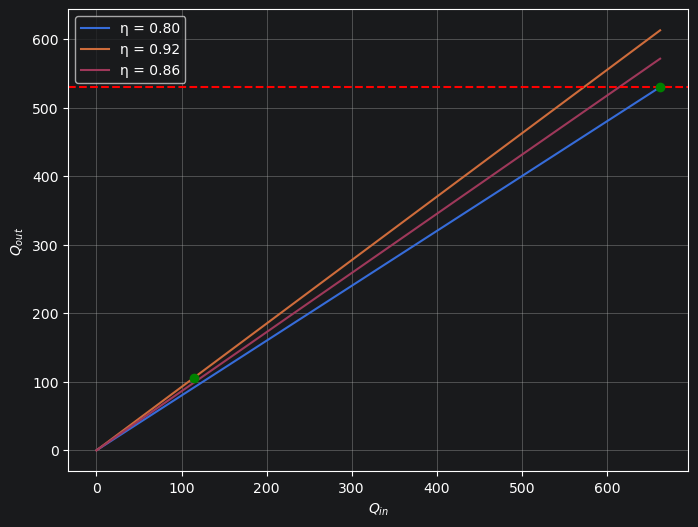

In [18]:
import numpy as np
import matplotlib.pyplot as plt

Q_in = np.linspace(0, Q_in_nom, 200)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(Q_in, eta_nom * Q_in, label=f"η = {eta_nom:.2f}")
ax.plot(Q_in, eta_min * Q_in, label=f"η = {eta_min:.2f}")
ax.plot(Q_in, eta_mean * Q_in, label=f"η = {eta_mean:.2f}")

ax.axhline(y=Q_out_nom, color="red", linestyle="--")

ax.scatter(
    [Q_in_nom, Q_in_min],
    [Q_out_nom, Q_out_min],
    color="green",
    zorder=3,
)

ax.set_xlabel(r"$Q_{in}$")
ax.set_ylabel(r"$Q_{out}$")
ax.legend()
ax.grid(True)

plt.show()